# Heart Disease Prediction from BRFSS2015 Health Indicators

## Project Aim
This project builds a machine learning pipeline that predicts whether someone has had heart
disease or a heart attack. It uses self-reported health indicators from the 2015 CDC
Behavioral Risk Factor Surveillance System (BRFSS) survey. The goal is to walk through a
complete, leakage-free ML workflow, from raw data to a final and honestly evaluated model,
rather than to build something ready for clinical use.

## Dataset
`heart_disease_health_indicators_BRFSS2015.csv`: 253,680 survey responses, 21 health and
lifestyle features (BMI, blood pressure, cholesterol, smoking, physical activity, and more),
and a binary target variable, `HeartDiseaseorAttack`.

## Team & Roles

| Student | Role | Name |
|---|---|---|
| Student 1 | Data Collection | Marcus Nathanael Priyan |
| Student 2 | Data Cleaning & EDA | Nilofarbanu Latifali Saiyad |
| Student 3 | Feature Engineering | Jaweria |
| Student 4 | Modeling | Aishwarya Suresh |
| Student 5 | Evaluation & Presentation | Saketh Rishi Nallagondla |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Duplicates are removed right after loading, before any split, so the same person's
# data can't end up in more than one split.
df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv').drop_duplicates().reset_index(drop=True)

print("Data Shape:", df.shape)
df.head()

Data Shape: (229781, 22)


# Phase 2: Train / Validation / Test Split

We split the data into three parts before any cleaning or scaling, to avoid data leakage:

- Train: 50%
- Validation: 25%
- Test: 25%

The validation set lets us compare models and pick the best one, while the test set stays
untouched until the final check.

In [2]:
X = df.drop(columns=['HeartDiseaseorAttack'])
y = df['HeartDiseaseorAttack']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(1/3), random_state=42, stratify=y_temp
)

total = len(df)
print(f"Train Set:      {len(X_train)} rows ({len(X_train)/total*100:.1f}%)")
print(f"Validation Set: {len(X_val)} rows ({len(X_val)/total*100:.1f}%)")
print(f"Test Set:       {len(X_test)} rows ({len(X_test)/total*100:.1f}%)")

Train Set:      114890 rows (50.0%)
Validation Set: 57445 rows (25.0%)
Test Set:       57446 rows (25.0%)


# Phase 3: Data Audit & Cleaning

We check the training set for missing values and summary statistics before doing anything
else, so problems get caught early instead of building on bad data. Duplicates were already
removed before the split, so there's nothing left to remove here.

In [3]:
missing_vals = X_train.isnull().sum()
print("Missing values per column in X_train:")
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found!")

print(f"\nDuplicate rows in X_train: {X_train.duplicated().sum()}")

print("\nSummary Statistics of X_train:")
X_train.describe().T[['mean', 'std', 'min', '50%', 'max']]

Missing values per column in X_train:
No missing values found!

Duplicate rows in X_train: 274

Summary Statistics of X_train:


# Phase 4: Exploratory Data Analysis (EDA)

Before building anything, we look at the split sizes, target balance, BMI distribution, and
feature correlations to understand what we're working with. This is where we noticed the
target is heavily imbalanced, which shaped several decisions later on.

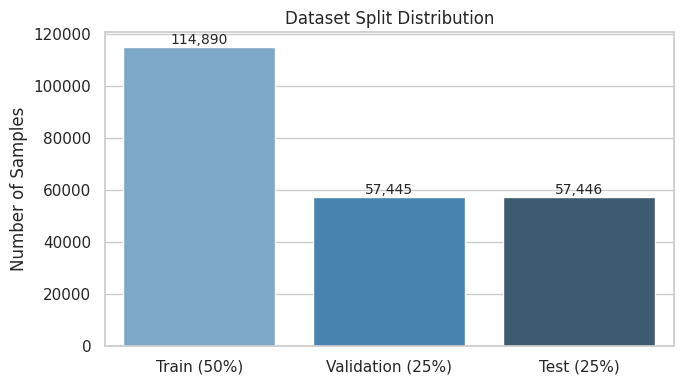

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))

split_sizes = {'Train (50%)': len(X_train), 'Validation (25%)': len(X_val), 'Test (25%)': len(X_test)}
ax = sns.barplot(x=list(split_sizes.keys()), y=list(split_sizes.values()), hue=list(split_sizes.keys()), palette='Blues_d', legend=False)

plt.title('Dataset Split Distribution')
plt.ylabel('Number of Samples')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

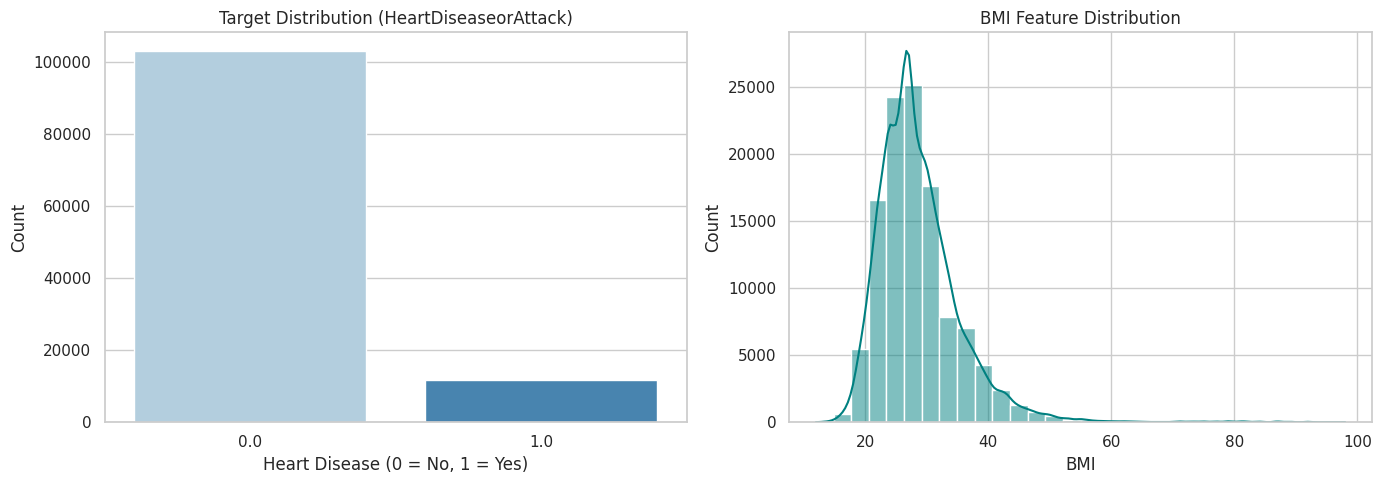

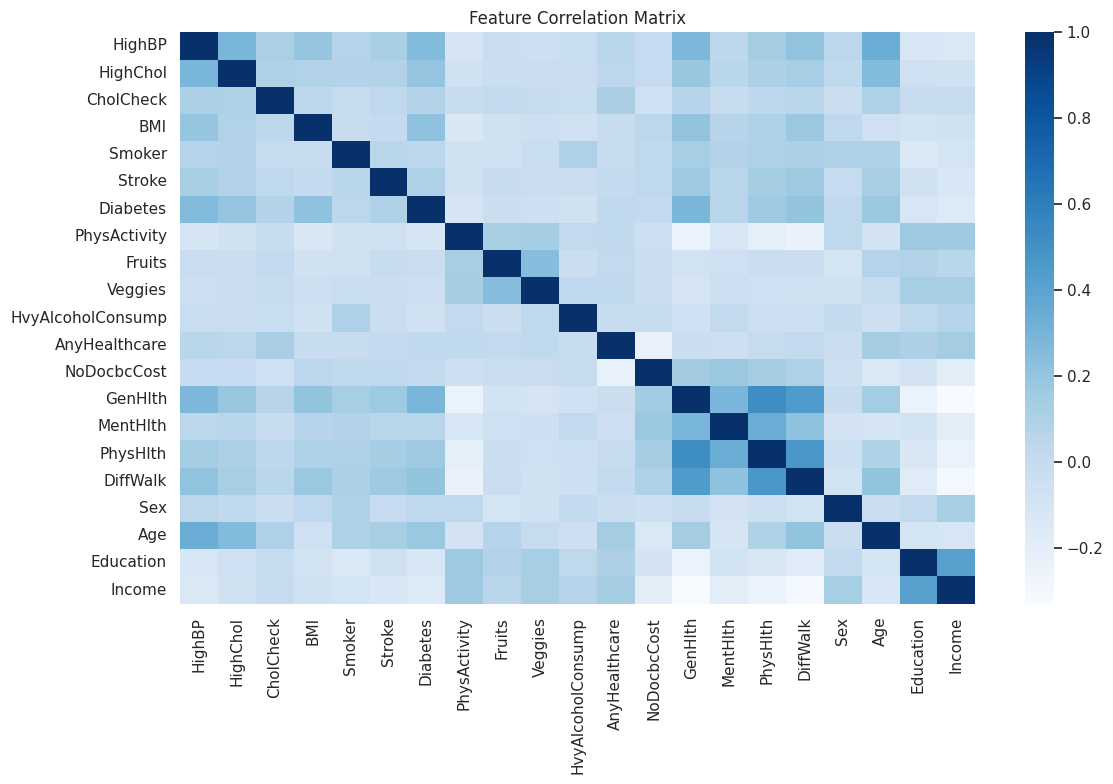

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train, hue=y_train, ax=axes[0], palette='Blues', legend=False)
axes[0].set_title('Target Distribution (HeartDiseaseorAttack)')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

sns.histplot(X_train['BMI'], kde=True, bins=30, ax=axes[1], color='teal')
axes[1].set_title('BMI Feature Distribution')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), cmap='Blues', annot=False, cbar=True)
plt.title('Feature Correlation Matrix')
plt.show()

# Phase 5: Exporting Cleaned Datasets

Saving all three splits to `Data/processed/` so later steps always use the same rows.

In [6]:
import os

processed_dir = 'Data/processed'
os.makedirs(processed_dir, exist_ok=True)

X_train.to_csv(f'{processed_dir}/X_train_clean.csv', index=False)
y_train.to_csv(f'{processed_dir}/y_train_clean.csv', index=False)
X_val.to_csv(f'{processed_dir}/X_val_clean.csv', index=False)
y_val.to_csv(f'{processed_dir}/y_val_clean.csv', index=False)
X_test.to_csv(f'{processed_dir}/X_test_clean.csv', index=False)
y_test.to_csv(f'{processed_dir}/y_test_clean.csv', index=False)

print("All clean datasets (train/val/test) successfully exported to 'Data/processed/' directory!")

All clean datasets (train/val/test) successfully exported to 'Data/processed/' directory!


# Feature Engineering

Raw columns alone don't always tell the full story, so we combined some of them into 10
new features that capture health risk patterns more directly.

- `ObesityFlag`: BMI of 30 or higher
- `CurrentSmokerFlag` / `FormerSmokerFlag`: current vs former smoking status
- `HeavyDrinkFlag`: heavy alcohol consumption
- `MentalHealthBurden`: poor mental health days
- `PhysicallyActiveFlag`: reported physical activity
- `CardiometabolicRiskScore`: combines obesity, high blood pressure, high cholesterol,
  diabetes, and stroke history into one risk score
- `AgeRiskTier`: age grouped into risk bands
- `HealthcareAccessRisk`: barriers to doctor visits
- `SocialIsolationProxy`: poor general health combined with high mental health burden

All features are applied the same way to train, validation, and test, through one shared
function, so the same logic is used everywhere.

In [7]:
def engineer_features(X):
    """Builds all engineered features, applied identically to train, validation, and test."""
    X = X.copy()

    # Obesity classification (BMI-based)
    X['ObesityFlag'] = (X['BMI'] >= 30).astype(int)

    # Tobacco exposure
    X['CurrentSmokerFlag'] = (X['Smoker'] == 1).astype(int)
    X['FormerSmokerFlag'] = (X['Smoker'] == 2).astype(int)

    # Alcohol misuse
    X['HeavyDrinkFlag'] = (X['HvyAlcoholConsump'] == 1).astype(int)

    # Mental health burden
    X['MentalHealthBurden'] = X.get('MentHlth', 0) + X.get('Depressed', 0)

    # Physical activity
    X['PhysicallyActiveFlag'] = (X['PhysActivity'] == 1).astype(int)

    # Merged cardiometabolic / metabolic syndrome risk score
    # Combines the two original overlapping scores into one: obesity, high BP,
    # high cholesterol, diabetes, and stroke history.
    X['CardiometabolicRiskScore'] = (
        X['ObesityFlag'] + X['HighBP'] + X['HighChol'] + X['Diabetes'] + X['Stroke']
    )

    # Age risk tiering
    X['AgeRiskTier'] = pd.cut(
        X['Age'], bins=[0, 34, 49, 64, 120],
        labels=['Low', 'Moderate', 'High', 'Very High']
    )

    # Healthcare access risk
    def _flag(col):
        val = X.get(col, 0)
        return (val == 1).astype(int) if isinstance(val, pd.Series) else int(val == 1)
    X['HealthcareAccessRisk'] = _flag('NoDocbcCost') + _flag('NoHealthInsurance')

    # Social isolation proxy
    X['SocialIsolationProxy'] = (
        (X['GenHlth'] >= 4).astype(int) + (X['MentHlth'] > 10).astype(int)
    )

    return X

X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
X_test = engineer_features(X_test)

print("Feature engineering applied to Train, Validation, and Test sets.")
print(f"X_train shape: {X_train.shape} | X_val shape: {X_val.shape} | X_test shape: {X_test.shape}")

Feature engineering applied to Train, Validation, and Test sets.
X_train shape: (114890, 31) | X_val shape: (57445, 31) | X_test shape: (57446, 31)


# Phase 6: Model Building

Numerical features are scaled and categorical features are one-hot encoded, fit on the
training set only so no information from validation or test leaks in. Three models are
trained and compared on validation, then the best one is checked once on the test set.

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'CardiometabolicRiskScore',
                      'MentalHealthBurden', 'HealthcareAccessRisk', 'SocialIsolationProxy']

categorical_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity',
                        'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
                        'DiffWalk', 'Sex', 'Education', 'Income', 'ObesityFlag', 'CurrentSmokerFlag',
                        'FormerSmokerFlag', 'HeavyDrinkFlag', 'AgeRiskTier']

numerical_features = [f for f in numerical_features if f in X_train.columns]
categorical_features = [f for f in categorical_features if f in X_train.columns]

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_features])
X_val_num = scaler.transform(X_val[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

X_train_num_df = pd.DataFrame(X_train_num, columns=numerical_features, index=X_train.index)
X_val_num_df = pd.DataFrame(X_val_num, columns=numerical_features, index=X_val.index)
X_test_num_df = pd.DataFrame(X_test_num, columns=numerical_features, index=X_test.index)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_val_cat = encoder.transform(X_val[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

encoded_names = encoder.get_feature_names_out(categorical_features)
X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_names, index=X_train.index)
X_val_cat_df = pd.DataFrame(X_val_cat, columns=encoded_names, index=X_val.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_names, index=X_test.index)

X_train_processed = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
X_val_processed = pd.concat([X_val_num_df, X_val_cat_df], axis=1)
X_test_processed = pd.concat([X_test_num_df, X_test_cat_df], axis=1)

print("Features processed successfully!")
print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_val shape:   {X_val_processed.shape}")
print(f"Processed X_test shape:  {X_test_processed.shape}")

Features processed successfully!
Processed X_train shape: (114890, 64)
Processed X_val shape:   (57445, 64)
Processed X_test shape:  (57446, 64)


## Model Training and Evaluation: K-Nearest Neighbors (KNN)

K-Nearest Neighbors model trained successfully!

### KNN Validation Metrics ###
Accuracy: 0.8872
Precision: 0.3808
Recall: 0.1479
F1-Score: 0.2131


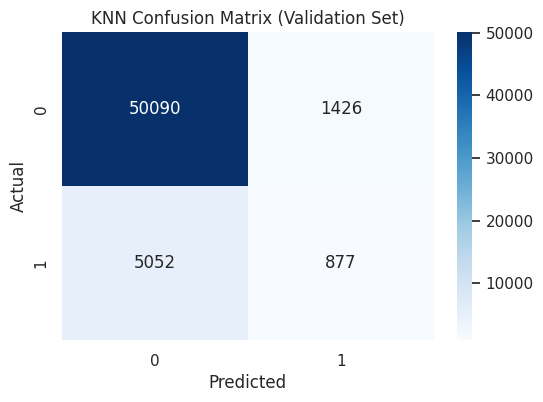

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed, y_train)
print("K-Nearest Neighbors model trained successfully!")

y_pred_knn_val = knn_model.predict(X_val_processed)
metrics_knn_val = {
    'Accuracy': accuracy_score(y_val, y_pred_knn_val),
    'Precision': precision_score(y_val, y_pred_knn_val),
    'Recall': recall_score(y_val, y_pred_knn_val),
    'F1-Score': f1_score(y_val, y_pred_knn_val),
}
print("\n### KNN Validation Metrics ###")
for k, v in metrics_knn_val.items():
    print(f"{k}: {v:.4f}")

cm_knn = confusion_matrix(y_val, y_pred_knn_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Training and Evaluation: Decision Tree

Decision Tree model trained successfully!

### Decision Tree Validation Metrics ###
Accuracy: 0.8331
Precision: 0.2419
Recall: 0.2889
F1-Score: 0.2633


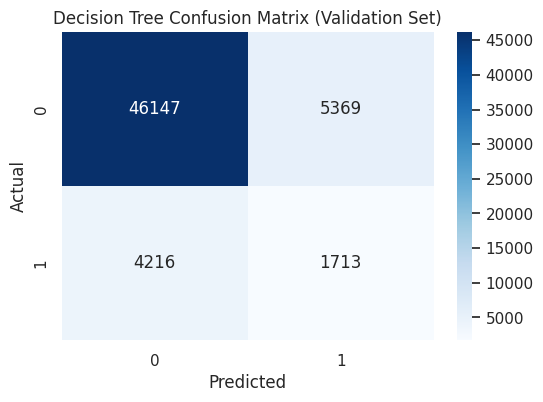

In [10]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_processed, y_train)
print("Decision Tree model trained successfully!")

y_pred_dt_val = decision_tree_model.predict(X_val_processed)
metrics_dt_val = {
    'Accuracy': accuracy_score(y_val, y_pred_dt_val),
    'Precision': precision_score(y_val, y_pred_dt_val),
    'Recall': recall_score(y_val, y_pred_dt_val),
    'F1-Score': f1_score(y_val, y_pred_dt_val),
}
print("\n### Decision Tree Validation Metrics ###")
for k, v in metrics_dt_val.items():
    print(f"{k}: {v:.4f}")

cm_dt = confusion_matrix(y_val, y_pred_dt_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Training and Evaluation: Random Forest

Random Forest model trained successfully!

### Random Forest Validation Metrics ###
Accuracy: 0.8923
Precision: 0.4211
Recall: 0.1157
F1-Score: 0.1815


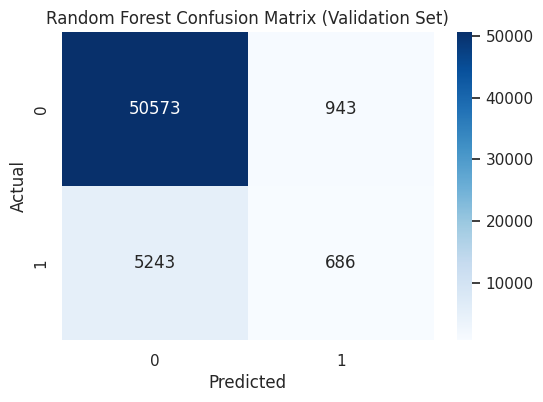

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)
print("Random Forest model trained successfully!")

y_pred_rf_val = rf_model.predict(X_val_processed)
metrics_rf_val = {
    'Accuracy': accuracy_score(y_val, y_pred_rf_val),
    'Precision': precision_score(y_val, y_pred_rf_val),
    'Recall': recall_score(y_val, y_pred_rf_val),
    'F1-Score': f1_score(y_val, y_pred_rf_val),
}
print("\n### Random Forest Validation Metrics ###")
for k, v in metrics_rf_val.items():
    print(f"{k}: {v:.4f}")

cm_rf = confusion_matrix(y_val, y_pred_rf_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Phase 7: Model Selection & Final Test Evaluation

We compare all three models on validation first, which lets us pick a winner without ever
touching the test set, keeping that final score honest.

### Validation Set Comparison ###
               Accuracy  Precision  Recall  F1-Score
KNN              0.8872     0.3808  0.1479    0.2131
Decision Tree    0.8331     0.2419  0.2889    0.2633
Random Forest    0.8923     0.4211  0.1157    0.1815

Best model by Validation F1-Score: Decision Tree

### Decision Tree - Final Test Set Metrics ###
Accuracy: 0.8342
Precision: 0.2379
Recall: 0.2749
F1-Score: 0.2550


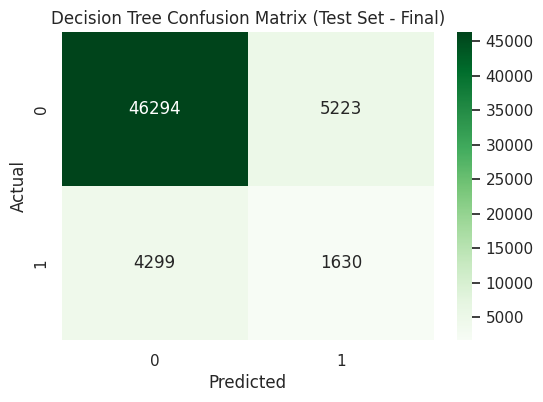

In [12]:
comparison = pd.DataFrame({
    'KNN': metrics_knn_val,
    'Decision Tree': metrics_dt_val,
    'Random Forest': metrics_rf_val,
}).T

print("### Validation Set Comparison ###")
print(comparison.round(4))

best_model_name = comparison['F1-Score'].idxmax()
best_model = {'KNN': knn_model, 'Decision Tree': decision_tree_model, 'Random Forest': rf_model}[best_model_name]
print(f"\nBest model by Validation F1-Score: {best_model_name}")

y_pred_test = best_model.predict(X_test_processed)
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test),
    'Recall': recall_score(y_test, y_pred_test),
    'F1-Score': f1_score(y_test, y_pred_test),
}
print(f"\n### {best_model_name} - Final Test Set Metrics ###")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")

cm_final = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title(f'{best_model_name} Confusion Matrix (Test Set - Final)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

KNN, Decision Tree, and Random Forest were compared on validation, and the winning
model's test set performance is shown above.

# Phase 8: Evaluation & Conclusion

Accuracy alone is misleading here since only about 9% of people in the dataset have had
heart disease. A model that always predicts "No" would still score around 90% accuracy
while catching nothing. We compared models using F1-Score instead.

## Model Comparison (Validation Set)

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| KNN | 0.887 | 0.381 | 0.148 | 0.213 |
| **Decision Tree** | 0.833 | 0.242 | 0.289 | **0.263** |
| Random Forest | 0.892 | 0.421 | 0.116 | 0.182 |

Decision Tree was selected despite the lowest accuracy, since it caught more real cases
than the other two models. KNN and Random Forest looked stronger on accuracy but missed
most positive cases.

Test set results were close to validation, so the model isn't overfitting.

## Limitations

- Class imbalance (about 9% positive cases) means even our best model misses most real
  cases. None of the three models are strong enough for clinical use as-is.
- No hyperparameter tuning, class weighting, or resampling was used, to keep the pipeline
  simple and explainable.

## Conclusion

The pipeline works end to end and is free of data leakage, but its value here is
educational rather than clinical. With more time, addressing class imbalance would be the
biggest improvement.